In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.getcwd()
os.listdir()


['.config', 'drive', 'sample_data']

In [3]:
os.chdir(r'drive/MyDrive/Colab Notebooks/Give Me Some Credit')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import optuna


In [5]:
df = pd.read_csv('cs-training.csv')

In [6]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# sns.pairplot(df, hue='SeriousDlqin2yrs')

In [11]:
df.corr()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Unnamed: 0,1.000000,0.002801,0.002372,0.004403,-0.000571,-0.002906,0.002632,0.004586,-0.001104,-0.000666,-0.000777,-0.000055
SeriousDlqin2yrs,0.002801,1.000000,-0.001802,-0.115386,0.125587,-0.007602,-0.019746,-0.029669,0.117175,-0.007038,0.102261,0.046048
RevolvingUtilizationOfUnsecuredLines,0.002372,-0.001802,1.000000,-0.005898,-0.001314,0.003961,0.007124,-0.011281,-0.001061,0.006235,-0.001048,0.001557
age,0.004403,-0.115386,-0.005898,1.000000,-0.062995,0.024188,0.037717,0.147705,-0.061005,0.033150,-0.057159,-0.213303
NumberOfTime30-59DaysPastDueNotWorse,-0.000571,0.125587,-0.001314,-0.062995,1.000000,-0.006542,-0.010217,-0.055312,0.983603,-0.030565,0.987005,-0.002680
DebtRatio,-0.002906,-0.007602,0.003961,0.024188,-0.006542,1.000000,-0.028712,0.049565,-0.008320,0.120046,-0.007533,-0.040673
MonthlyIncome,0.002632,-0.019746,0.007124,0.037717,-0.010217,-0.028712,1.000000,0.091455,-0.012743,0.124959,-0.011116,0.062647
NumberOfOpenCreditLinesAndLoans,0.004586,-0.029669,-0.011281,0.147705,-0.055312,0.049565,0.091455,1.000000,-0.079984,0.433959,-0.071077,0.065322
NumberOfTimes90DaysLate,-0.001104,0.117175,-0.001061,-0.061005,0.983603,-0.008320,-0.012743,-0.079984,1.000000,-0.045205,0.992796,-0.010176
NumberRealEstateLoansOrLines,-0.000666,-0.007038,0.006235,0.033150,-0.030565,0.120046,0.124959,0.433959,-0.045205,1.000000,-0.039722,0.124684


<Axes: >

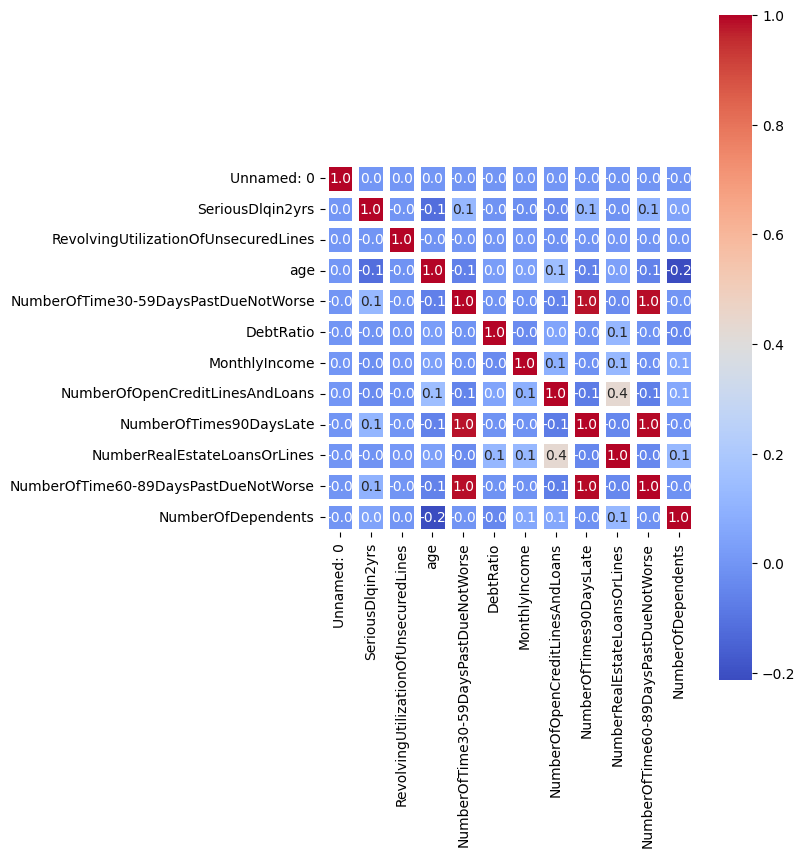

In [12]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=5, linecolor='white', fmt='.01f', cbar_kws={'shrink': 1.8}, square=True)

<Axes: xlabel='age'>

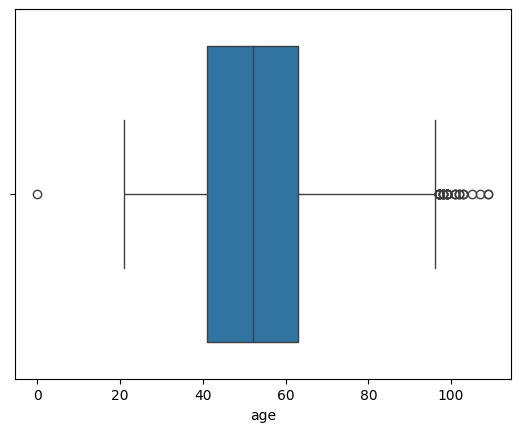

In [13]:
sns.boxplot(x='age', data=df)

<Axes: xlabel='MonthlyIncome'>

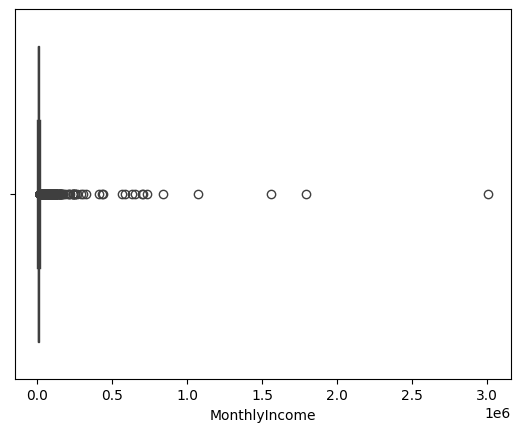

In [14]:
sns.boxplot(x='MonthlyIncome', data=df)

<Axes: xlabel='DebtRatio'>

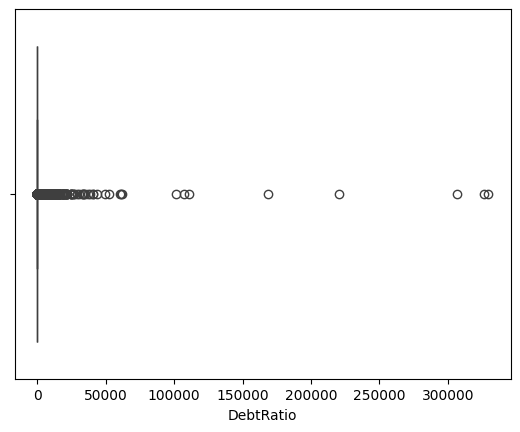

In [15]:
sns.boxplot(x='DebtRatio', data=df)

<Axes: xlabel='NumberRealEstateLoansOrLines'>

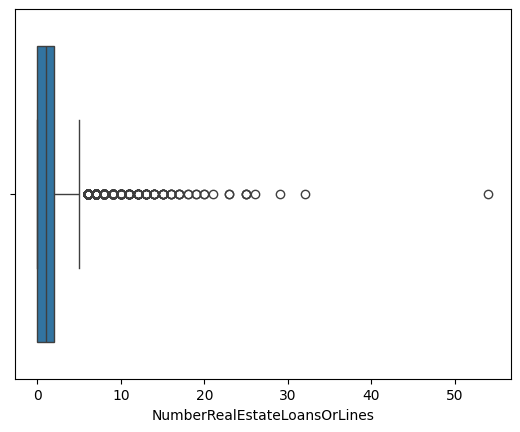

In [16]:
sns.boxplot(x='NumberRealEstateLoansOrLines', data=df)

<Axes: xlabel='NumberOfOpenCreditLinesAndLoans'>

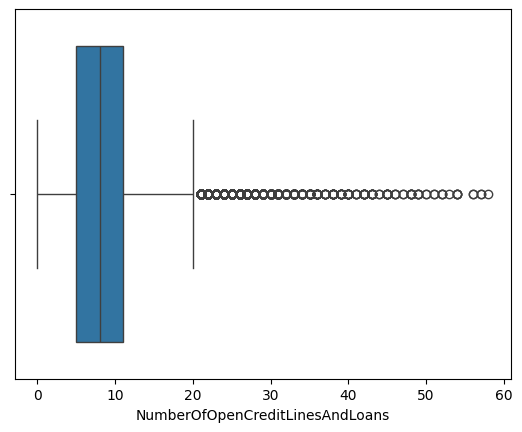

In [17]:
sns.boxplot(x='NumberOfOpenCreditLinesAndLoans', data=df)

<Axes: xlabel='DebtRatio'>

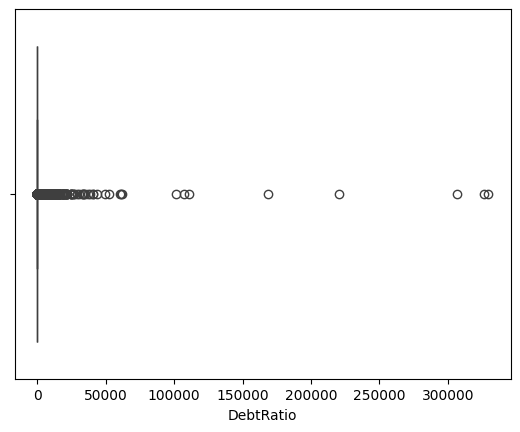

In [18]:
sns.boxplot(x='DebtRatio', data=df)

In [19]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [20]:
df.shape

(150000, 12)

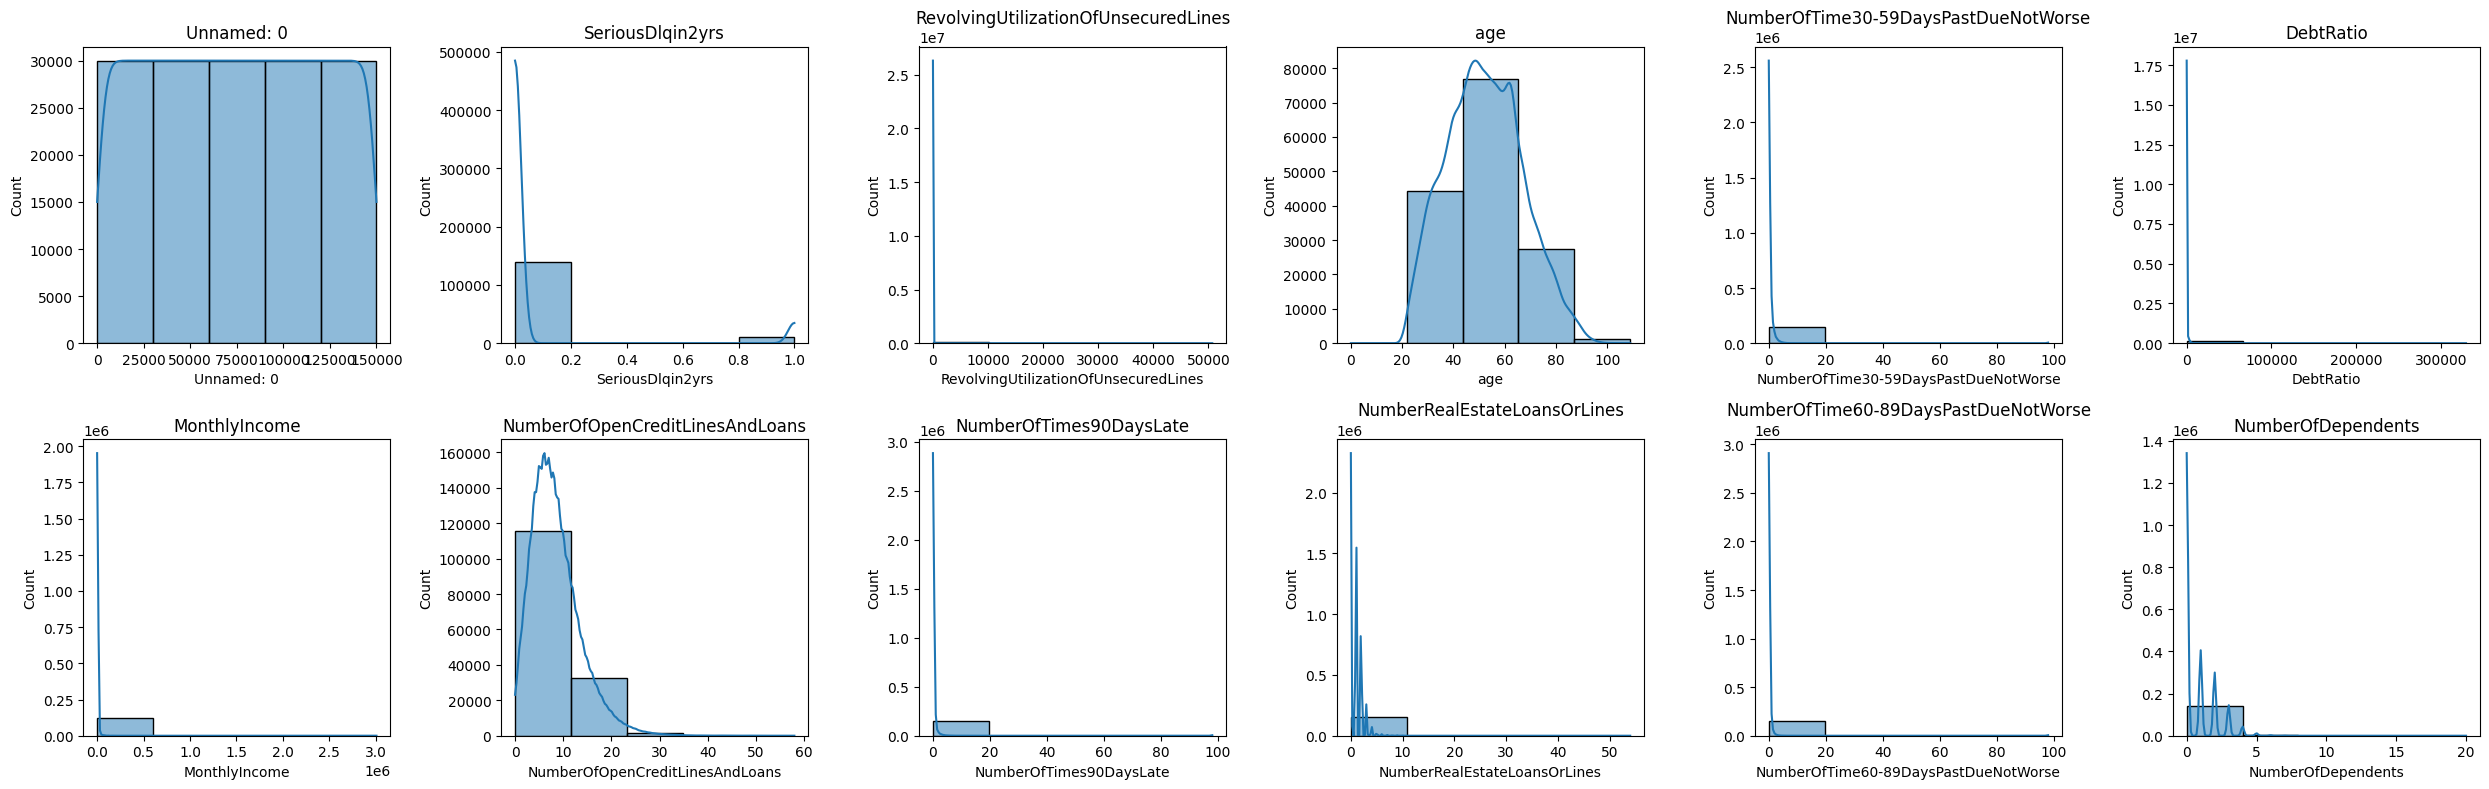

In [21]:
features = ['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents']

fig, ax = plt.subplots(2, 6, figsize=(25, 8))
ax = ax.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], bins=5, kde=True, ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xlabel(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='RevolvingUtilizationOfUnsecuredLines', ylabel='Count'>

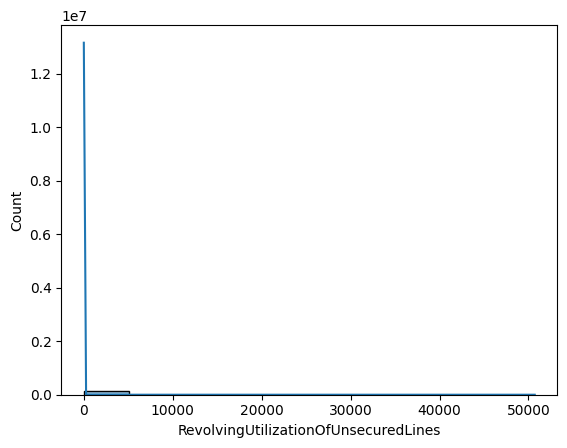

In [22]:
sns.histplot(df['RevolvingUtilizationOfUnsecuredLines'], bins=10, kde=True)

In [23]:
df.skew()

,0
Unnamed: 0,0.000000
SeriousDlqin2yrs,3.468857
RevolvingUtilizationOfUnsecuredLines,97.631574
age,0.188995
NumberOfTime30-59DaysPastDueNotWorse,22.597108
DebtRatio,95.157793
MonthlyIncome,114.040318
NumberOfOpenCreditLinesAndLoans,1.215314
NumberOfTimes90DaysLate,23.087345
NumberRealEstateLoansOrLines,3.482484


In [24]:
df['RevolvingUtilizationOfUnsecuredLines'].describe()

,RevolvingUtilizationOfUnsecuredLines
count,150000.000000
mean,6.048438
std,249.755371
min,0.000000
25%,0.029867
50%,0.154181
75%,0.559046
max,50708.000000


In [25]:
X = df.drop(['SeriousDlqin2yrs', 'Unnamed: 0'], axis=1)
y = df['SeriousDlqin2yrs']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.isnull().sum()

,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,23689
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0
NumberOfDependents,3127


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Columns
num_cols = [
    'age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio',
    'MonthlyIncome', 'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

log_col = ['NumberOfOpenCreditLinesAndLoans']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   
    ('pt', PowerTransformer()),
    ('scaler', StandardScaler())
])
Transformer = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('log', FunctionTransformer(func=np.log1p), log_col)
], remainder='passthrough')

final_pipeline = Pipeline([
    ('preprocessing', Transformer)
])

final_pipeline.fit(X_train)

X_train_transformed = final_pipeline.transform(X_train)
X_test_transformed  = final_pipeline.transform(X_test)

In [33]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.2 MB/s eta 0:00:00


In [48]:
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='auc')
xgb_clf.fit( X_train_transformed, y_train)


cross_val_score(xgb_clf, X_train_transformed, y_train, cv=5, scoring='roc_auc').mean()

np.float64(0.8529955851766532)

In [ ]:
import xgboost as xgb
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['xgb', 'BalancedRandomForestClassifier', 'LogisticRegression'])

    if classifier_name == 'xgb':
        # XGBoost hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)

        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth
        )

    elif classifier_name == 'BalancedRandomForestClassifier':
        # Balanced Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = BalancedRandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )


    elif classifier_name == 'LogisticRegression':
        # Logistic Regression hyperparameters
        C = trial.suggest_float('C', 0.01, 100, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])

        model = LogisticRegression(C=C, penalty=penalty, solver=solver, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train_transformed, y_train, cv=3, scoring='roc_auc').mean()
    return score

In [46]:
# Create a study and optimize it using CmaEsSampler
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-04-15 17:37:40,206] A new study created in memory with name: no-name-cfb22502-bf7a-4b1e-85cc-2590e4decc4f
[I 2026-04-15 17:38:01,111] Trial 0 finished with value: 0.862932330914469 and parameters: {'classifier': 'BalancedRandomForestClassifier', 'n_estimators': 185, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.862932330914469.
[I 2026-04-15 17:38:01,619] Trial 1 finished with value: 0.8502844947237005 and parameters: {'classifier': 'LogisticRegression', 'C': 0.022926186130018417, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 0 with value: 0.862932330914469.
[I 2026-04-15 17:38:03,320] Trial 2 finished with value: 0.8512473077138957 and parameters: {'classifier': 'LogisticRegression', 'C': 0.5349815942599292, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.862932330914469.
[I 2026-04-15 17:38:05,126] Trial 3 finished with value: 0.8512439765028396 and parameters: {'classifier': 'LogisticRegression'

KeyboardInterrupt: 